# Sentiment Analysis

## Oasis Infobyte Internship

Name: Prince Kumar  
Track: Data Analytics  
Level: Level 1  
Task: Task 4 - Sentiment Analysis  





## Objective

The objective of this project is to build a machine learning model
that classifies text data into positive, negative, or neutral sentiment.

The project includes text preprocessing, TF-IDF feature extraction,
machine learning classification, model evaluation, visualization,
and error analysis.

In [2]:
#import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#file upload
from google.colab import files

uploaded = files.upload()

Saving twitter_training.csv to twitter_training.csv
Saving twitter_validation.csv to twitter_validation.csv


In [4]:
#Dataset load and Basic Inspection
df = pd.read_csv("twitter_training.csv")
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (74681, 4)

Column Names:
['2401', 'Borderlands', 'Positive', 'im getting on borderlands and i will murder you all ,']

First 5 Rows:


,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [5]:
#Dataset Quality & Sentiment Distribution
print("Dataset Information:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB
None

Missing Values:
2401                                                       0
Borderlands                                                0
Positive                                                   0
im getting on borderlands and i will murder you all ,    686
dtype: int64

Duplicate Rows: 2700


In [6]:
#sentiment column identify
print("\nUnique Values in Each Column:")

for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique()[:20])


Unique Values in Each Column:

2401:
[2401 2402 2403 2404 2405 2406 2407 2408 2409 2410 2411 2412 2413 2414
 2415 2416 2417 2418 2419 2420]

Borderlands:
['Borderlands' 'CallOfDutyBlackopsColdWar' 'Amazon' 'Overwatch'
 'Xbox(Xseries)' 'NBA2K' 'Dota2' 'PlayStation5(PS5)' 'WorldOfCraft'
 'CS-GO' 'Google' 'AssassinsCreed' 'ApexLegends' 'LeagueOfLegends'
 'Fortnite' 'Microsoft' 'Hearthstone' 'Battlefield'
 'PlayerUnknownsBattlegrounds(PUBG)' 'Verizon']

Positive:
['Positive' 'Neutral' 'Negative' 'Irrelevant']

im getting on borderlands and i will murder you all ,:
['I am coming to the borders and I will kill you all,'
 'im getting on borderlands and i will kill you all,'
 'im coming on borderlands and i will murder you all,'
 'im getting on borderlands 2 and i will murder you me all,'
 'im getting into borderlands and i can murder you all,'
 "So I spent a few hours making something for fun. . . If you don't know I am a HUGE @Borderlands fan and Maya is one of my favorite characters. So I 

In [7]:
#upload dataset in correct format
df = pd.read_csv(
    "twitter_training.csv",
    header=None,
    names=["ID", "Entity", "Sentiment", "Text"]
)

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (74682, 4)

Column Names:
['ID', 'Entity', 'Sentiment', 'Text']

First 5 Rows:


,ID,Entity,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [8]:
#sentiment distribution
print("Sentiment Distribution:")
print(df["Sentiment"].value_counts())

Sentiment Distribution:
Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


In [9]:
#check percentage
print("\nSentiment Percentage:")
print((df["Sentiment"].value_counts(normalize=True) * 100).round(2))


Sentiment Percentage:
Sentiment
Negative      30.18
Positive      27.89
Neutral       24.53
Irrelevant    17.39
Name: proportion, dtype: float64


In [10]:
#Irrelevant records remove
df = df[df["Sentiment"] != "Irrelevant"].copy()

print("Dataset Shape After Removing Irrelevant:")
print(df.shape)

print("\nFinal Sentiment Distribution:")
print(df["Sentiment"].value_counts())

Dataset Shape After Removing Irrelevant:
(61692, 4)

Final Sentiment Distribution:
Sentiment
Negative    22542
Positive    20832
Neutral     18318
Name: count, dtype: int64


In [11]:
print("\nFinal Sentiment Percentage:")
print((df["Sentiment"].value_counts(normalize=True) * 100).round(2))


Final Sentiment Percentage:
Sentiment
Negative    36.54
Positive    33.77
Neutral     29.69
Name: proportion, dtype: float64


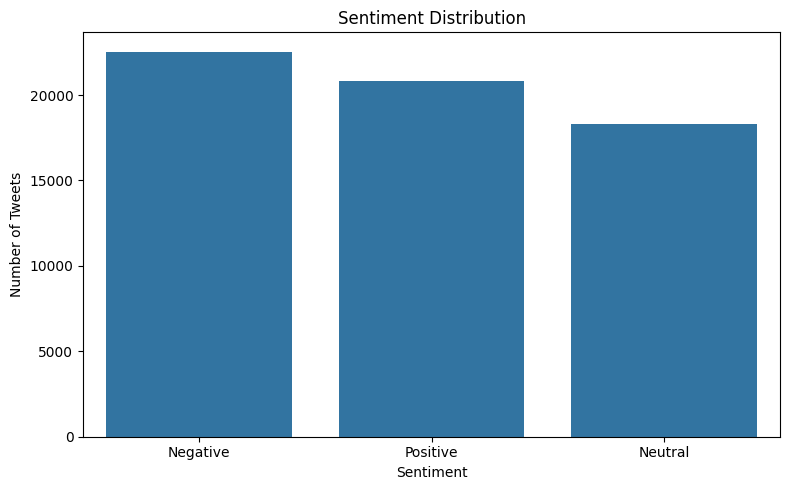

In [12]:
#Required Sentiment Distribution Bar Chart
sentiment_counts = df["Sentiment"].value_counts()
plt.figure(figsize=(8, 5))

sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.show()

In [13]:
#Missing Values & Duplicate Text Check
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nMissing Text Rows:", df["Text"].isnull().sum())

Missing Values:
ID             0
Entity         0
Sentiment      0
Text         571
dtype: int64

Duplicate Rows: 2294

Missing Text Rows: 571


In [14]:
print("Text Data Type:", df["Text"].dtype)

print("\nSample Text:")
display(df["Text"].head(10))

Text Data Type: object

Sample Text:


,Text
0,im getting on borderlands and i will murder yo...
1,I am coming to the borders and I will kill you...
2,im getting on borderlands and i will kill you ...
3,im coming on borderlands and i will murder you...
4,im getting on borderlands 2 and i will murder ...
5,im getting into borderlands and i can murder y...
6,So I spent a few hours making something for fu...
7,So I spent a couple of hours doing something f...
8,So I spent a few hours doing something for fun...
9,So I spent a few hours making something for fu...


In [15]:
#NLTK install/import
import nltk
import string
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [16]:
stop_words = set(stopwords.words("english"))

print("Number of English Stopwords:", len(stop_words))

Number of English Stopwords: 198


In [17]:
#Preprocessing Function
def preprocess_text(text):
    text = str(text).lower()

    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    text = text.translate(str.maketrans("", "", string.punctuation))

    tokens = word_tokenize(text)

    tokens = [
        word for word in tokens
        if word not in stop_words and word.isalpha()
    ]

    return " ".join(tokens)

In [18]:
#Function ko dataset par apply karo
df["Clean_Text"] = df["Text"].apply(preprocess_text)
display(df[["Text", "Clean_Text", "Sentiment"]].head(10))

,Text,Clean_Text,Sentiment
0,im getting on borderlands and i will murder yo...,im getting borderlands murder,Positive
1,I am coming to the borders and I will kill you...,coming borders kill,Positive
2,im getting on borderlands and i will kill you ...,im getting borderlands kill,Positive
3,im coming on borderlands and i will murder you...,im coming borderlands murder,Positive
4,im getting on borderlands 2 and i will murder ...,im getting borderlands murder,Positive
5,im getting into borderlands and i can murder y...,im getting borderlands murder,Positive
6,So I spent a few hours making something for fu...,spent hours making something fun dont know hug...,Positive
7,So I spent a couple of hours doing something f...,spent couple hours something fun dont know im ...,Positive
8,So I spent a few hours doing something for fun...,spent hours something fun dont know im huge bo...,Positive
9,So I spent a few hours making something for fu...,spent hours making something fun dont know hug...,Positive


In [19]:
#Empty cleaned text check
empty_text_count = (df["Clean_Text"].str.strip() == "").sum()
print("Empty Cleaned Text Rows:", empty_text_count)

Empty Cleaned Text Rows: 1453


In [20]:
#Empty Text Rows Handle
before_rows = len(df)

df = df[df["Clean_Text"].str.strip() != ""].copy()

after_rows = len(df)

print("Rows Before Removing Empty Text:", before_rows)
print("Rows Removed:", before_rows - after_rows)
print("Rows After Cleaning:", after_rows)

Rows Before Removing Empty Text: 61692
Rows Removed: 1453
Rows After Cleaning: 60239


In [21]:
print("Empty Cleaned Text Rows:", (df["Clean_Text"].str.strip() == "").sum())

Empty Cleaned Text Rows: 0


## Handling Empty Text Records

After text preprocessing, some records resulted in empty cleaned text because they did not contain usable textual content after removing punctuation, stopwords, URLs, and non-alphabetic tokens.

These records were removed because they do not provide meaningful text features for sentiment classification.

The original text column was retained for reference and error analysis.

## TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) is used to convert
text data into numerical feature vectors that can be processed by
machine learning algorithms.

It gives higher importance to words that are frequent in a particular
document but less common across the entire dataset.

TF-IDF helps represent the importance of words in each text document
while reducing the influence of very common words.

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(df["Clean_Text"])
y = df["Sentiment"]

print("TF-IDF Matrix Shape:", X.shape)
print("Number of Target Labels:", len(y))

TF-IDF Matrix Shape: (60239, 5000)
Number of Target Labels: 60239


In [23]:
#Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

print("\nTraining Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Data: (48191, 5000)
Testing Data: (12048, 5000)

Training Labels: (48191,)
Testing Labels: (12048,)


In [24]:
#Verify Split
print("Training Sentiment Distribution:")
print(y_train.value_counts())

print("\nTesting Sentiment Distribution:")
print(y_test.value_counts())

Training Sentiment Distribution:
Sentiment
Negative    17674
Positive    16267
Neutral     14250
Name: count, dtype: int64

Testing Sentiment Distribution:
Sentiment
Negative    4419
Positive    4067
Neutral     3562
Name: count, dtype: int64


In [25]:
#Naive Bayes import & training
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


In [26]:
#Predictions
y_pred_nb = nb_model.predict(X_test)
print("Predictions completed successfully.")
print("Number of Predictions:", len(y_pred_nb))

Predictions completed successfully.
Number of Predictions: 12048


In [27]:
#metrics imports:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [28]:
#metrics calculate
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, average="weighted")
recall_nb = recall_score(y_test, y_pred_nb, average="weighted")
f1_nb = f1_score(y_test, y_pred_nb, average="weighted")

print("Naive Bayes Performance")
print("------------------------")
print("Accuracy :", round(accuracy_nb, 4))
print("Precision:", round(precision_nb, 4))
print("Recall   :", round(recall_nb, 4))
print("F1-Score :", round(f1_nb, 4))

Naive Bayes Performance
------------------------
Accuracy : 0.7297
Precision: 0.7311
Recall   : 0.7297
F1-Score : 0.726


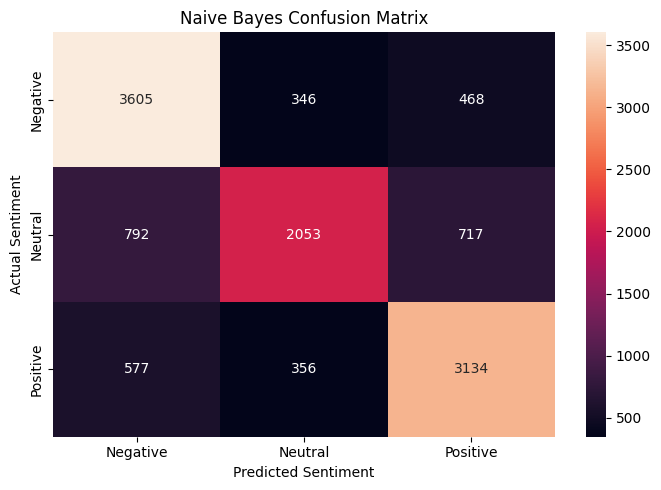

In [29]:
#Naive Bayes Confusion Matrix
cm_nb = confusion_matrix(
    y_test,
    y_pred_nb,
    labels=["Negative", "Neutral", "Positive"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

In [30]:
#Model Train
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [31]:
#find Predictions

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression predictions completed successfully.")
print("Number of Predictions:", len(y_pred_lr))

Logistic Regression predictions completed successfully.
Number of Predictions: 12048


In [32]:
#Accuracy, Precision, Recall & F1-Score

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average="weighted")
recall_lr = recall_score(y_test, y_pred_lr, average="weighted")
f1_lr = f1_score(y_test, y_pred_lr, average="weighted")

print("Logistic Regression Performance")
print("-------------------------------")
print("Accuracy :", round(accuracy_lr, 4))
print("Precision:", round(precision_lr, 4))
print("Recall   :", round(recall_lr, 4))
print("F1-Score :", round(f1_lr, 4))

Logistic Regression Performance
-------------------------------
Accuracy : 0.7634
Precision: 0.7627
Recall   : 0.7634
F1-Score : 0.7628


In [33]:
#Logistic Regression Classification Report
print("Logistic Regression Classification Report:")
print("------------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

Logistic Regression Classification Report:
------------------------------------------
              precision    recall  f1-score   support

    Negative       0.78      0.81      0.80      4419
     Neutral       0.73      0.69      0.71      3562
    Positive       0.77      0.77      0.77      4067

    accuracy                           0.76     12048
   macro avg       0.76      0.76      0.76     12048
weighted avg       0.76      0.76      0.76     12048



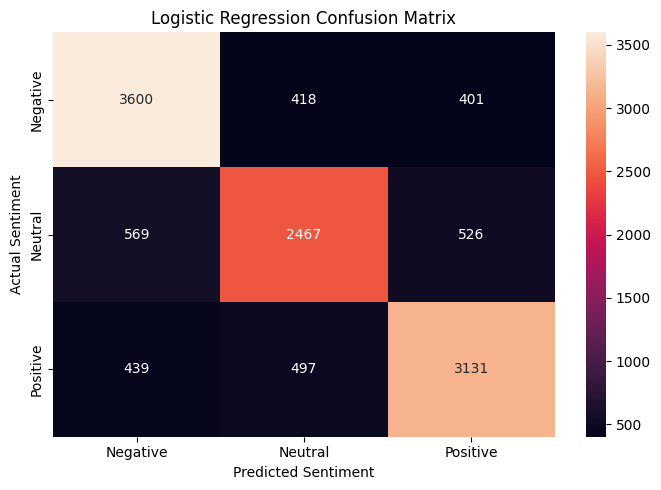

In [34]:
#Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr,
    labels=["Negative", "Neutral", "Positive"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

In [35]:
#Naive Bayes vs Logistic Regression
model_comparison = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [accuracy_nb, accuracy_lr],
    "Precision": [precision_nb, precision_lr],
    "Recall": [recall_nb, recall_lr],
    "F1-Score": [f1_nb, f1_lr]
})

display(model_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.7297,0.7311,0.7297,0.7260
1,Logistic Regression,0.7634,0.7627,0.7634,0.7628


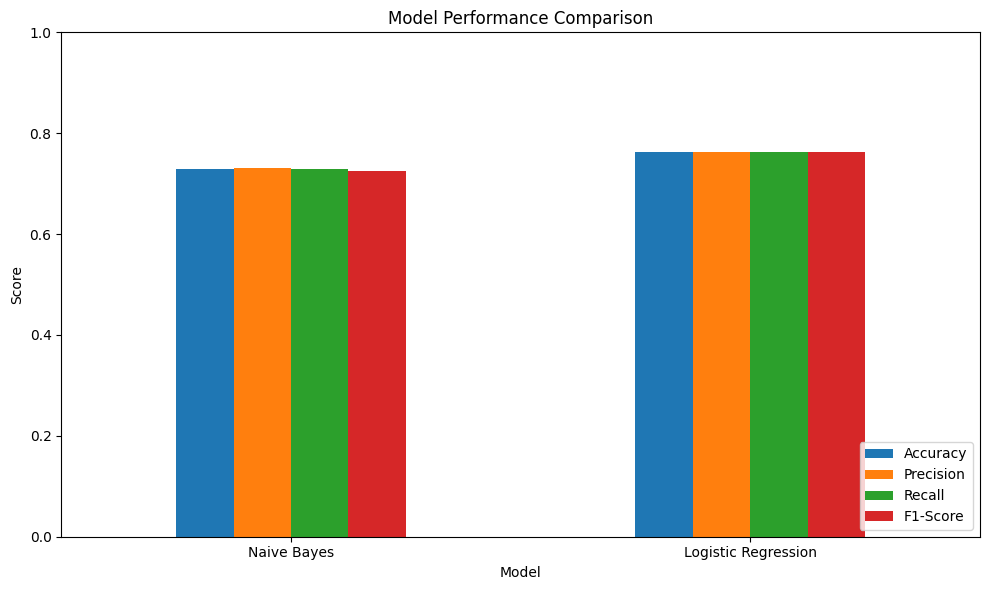

In [36]:
comparison_plot = model_comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [37]:
#WordCloud library
!pip install wordcloud

In [38]:
from wordcloud import WordCloud

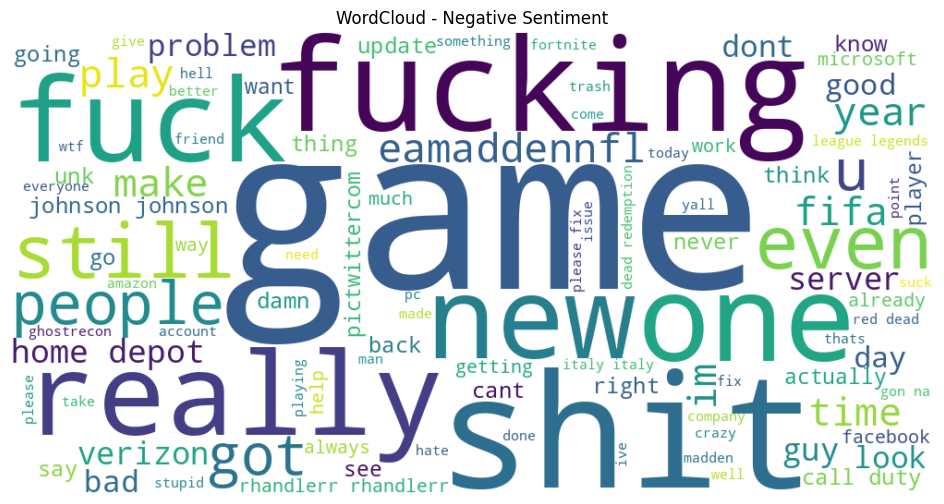

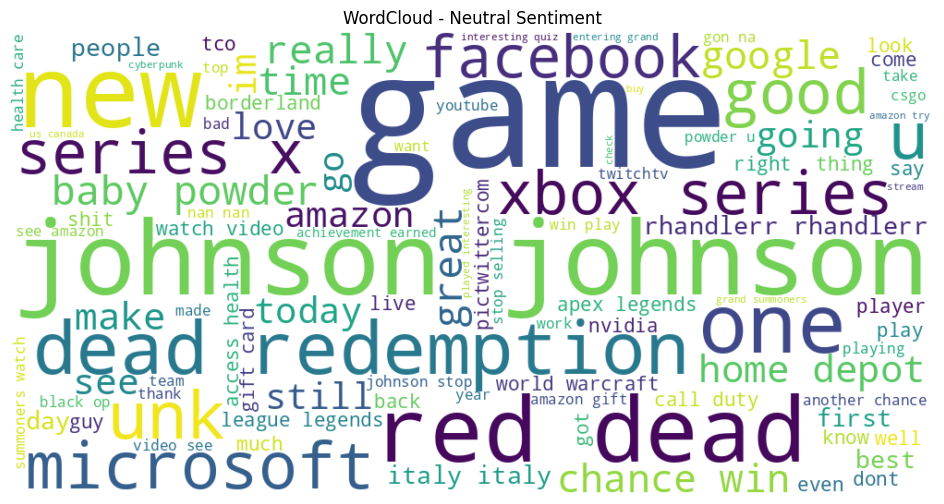

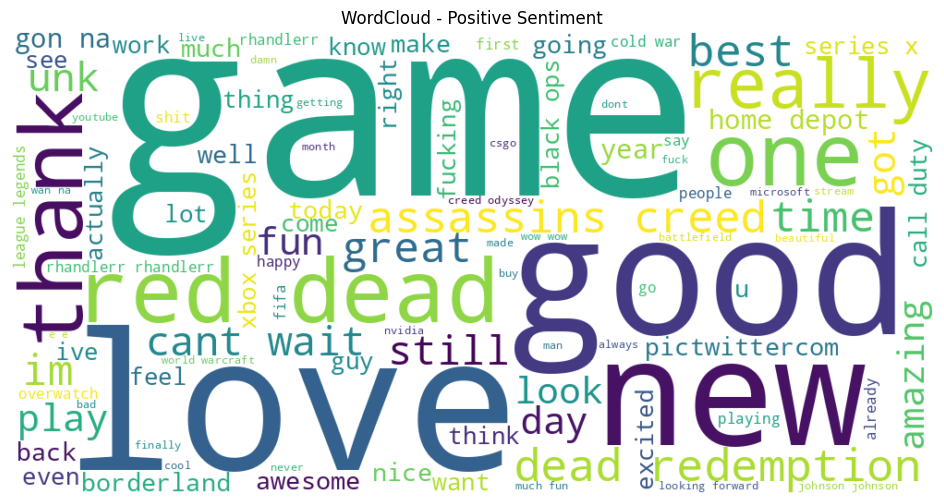

In [39]:
#WordCloud : Negative, Neutral & Positive

sentiments = ["Negative", "Neutral", "Positive"]

for sentiment in sentiments:

    text = " ".join(
        df[df["Sentiment"] == sentiment]["Clean_Text"]
    )

    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        max_words=100
    ).generate(text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud - {sentiment} Sentiment")
    plt.show()


In [40]:
#Misclassified Examples

# Create error analysis dataframe

error_analysis = pd.DataFrame({
    "Original Text": df.loc[y_test.index, "Text"].values,
    "Actual Sentiment": y_test.values,
    "Predicted Sentiment": y_pred_lr
})

# Keep only misclassified examples
misclassified = error_analysis[
    error_analysis["Actual Sentiment"] != error_analysis["Predicted Sentiment"]
].copy()

# Display 5 misclassified examples
display(misclassified.head(5))

,Original Text,Actual Sentiment,Predicted Sentiment
2,2nd time playing through Red Dead Redemption 2...,Positive,Neutral
7,Soup @ Rainbow6Game @ Ubis6Support. Me and my ...,Negative,Neutral
12,@NBA2K_MyTEAM good job with xp challenges peo...,Positive,Negative
16,A little good shucks to take you into a week o...,Negative,Positive
23,He @verizon,Neutral,Negative


## Error Analysis

The Logistic Regression model was analyzed to identify cases where the predicted sentiment differed from the actual sentiment.

Five misclassified examples were reviewed to understand possible reasons for incorrect predictions.

### Possible Reasons for Misclassification

1. **Ambiguous language:** Some tweets may contain words that can express different sentiments depending on the context.

2. **Sarcasm and irony:** Sarcastic statements can be difficult for a text classification model to interpret correctly.

3. **Short text:** Very short tweets may not contain enough meaningful words for accurate sentiment classification.

4. **Context dependency:** Some tweets require additional context about the topic or entity being discussed.

5. **Similar sentiment vocabulary:** Positive, negative, and neutral tweets may sometimes contain similar words, making classification difficult.

Overall, the errors show that traditional TF-IDF based models can perform well on sentiment classification but may struggle with context, sarcasm, and subtle language patterns.

## Final Model Performance Comparison

Two machine learning classifiers were trained and evaluated for sentiment classification:

- Multinomial Naive Bayes
- Logistic Regression

Both models were evaluated using accuracy, precision, recall, and F1-score.

In [41]:
# Display final model comparison

display(model_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.7297,0.7311,0.7297,0.7260
1,Logistic Regression,0.7634,0.7627,0.7634,0.7628


In [42]:
#Automatically Best Model identify
best_model = model_comparison.loc[
    model_comparison["F1-Score"].idxmax(), "Model"
]

best_f1 = model_comparison["F1-Score"].max()

print("Best Performing Model:", best_model)
print("Best F1-Score:", round(best_f1, 4))

Best Performing Model: Logistic Regression
Best F1-Score: 0.7628


## Conclusion

This project successfully developed a sentiment analysis system using
TF-IDF based text features and machine learning classification models.

The dataset was cleaned and preprocessed by converting text to lowercase,
removing URLs and punctuation, removing stopwords, and retaining useful
alphabetic tokens.

Two classification algorithms, Multinomial Naive Bayes and Logistic
Regression, were trained and evaluated using accuracy, precision, recall,
F1-score, and confusion matrices.

Based on the evaluation results, the model with the highest F1-score was
selected as the best-performing model.

### Real-World Applications

Sentiment analysis can be used in:

- Social media monitoring
- Customer feedback analysis
- Product and service reviews
- Brand reputation monitoring
- Customer support analysis
- Business decision-making

The project demonstrates how Natural Language Processing and machine
learning can be used to automatically understand sentiment from text data.

## Project Summary

### Dataset

The Twitter Sentiment Analysis (Entity-level) dataset was used for this project.

The dataset originally contained four labels:
- Positive
- Negative
- Neutral
- Irrelevant

The Irrelevant class was removed because the project objective focuses on
Positive, Negative, and Neutral sentiment classification.

### Data Preparation

The text data was:
- Converted to lowercase
- URLs removed
- Punctuation removed
- Tokenized
- English stopwords removed
- Non-alphabetic tokens removed
- Empty cleaned text records removed

### Machine Learning

TF-IDF was used to convert text into numerical features.

The dataset was divided into:
- 80% Training data
- 20% Testing data

Two classification models were trained:
- Multinomial Naive Bayes
- Logistic Regression

### Evaluation

Both models were evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- Classification Report
- Confusion Matrix

### Visualization

The project includes:
- Sentiment Distribution Bar Chart
- Negative Sentiment WordCloud
- Neutral Sentiment WordCloud
- Positive Sentiment WordCloud
- Model Performance Comparison Chart

### Error Analysis

Five misclassified examples were examined to understand common sources
of prediction errors.

In [43]:
print("===== FINAL PROJECT RESULTS =====")

print("\nDataset Shape:", df.shape)

print("\nSentiment Distribution:")
print(df["Sentiment"].value_counts())

print("\nModel Comparison:")
display(model_comparison.round(4))

print("\nBest Model:", best_model)
print("Best F1-Score:", round(best_f1, 4))

print("\nNumber of Misclassified Examples:",
      len(misclassified))

===== FINAL PROJECT RESULTS =====

Dataset Shape: (60239, 5)

Sentiment Distribution:
Sentiment
Negative    22093
Positive    20334
Neutral     17812
Name: count, dtype: int64

Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.7297,0.7311,0.7297,0.7260
1,Logistic Regression,0.7634,0.7627,0.7634,0.7628



Best Model: Logistic Regression
Best F1-Score: 0.7628

Number of Misclassified Examples: 2850
